# Install the Project requirements
this installs matplotlib and other necessary dependencies
you must have UV installed, use pip or your linux package manager

In [1]:
!uv sync

Resolved 61 packages in 0.90ms
⠙ Preparing packages... (0/20)                                                  
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
tqdm                 ------------------------------     0 B/76.74 KiB
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
tqdm                 ------------------------------     0 B/76.74 KiB
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
tqdm                 ------------------------------     0 B/76.74 KiB
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
requests             ------------------------------     0 B/71.36 KiB
tqdm                 ------------------------------     0 B/76.74 KiB
⠙ Preparing packages... (0/20)------------------     0 B/113.91 KiB          
requests             ------------------------------     0 B/71.36 KiB


# Get the data from the API
will request you to enter your secret key to get the data from the API
This will also import all required libaries

In [3]:
# Self coded tools for Data Exploration
from PreProcessing import PreProcess
from API import GovApi,Search
API = GovApi()
# Libaries for plotting data
import pandas as pd
import seaborn as sns
import matplotlib as plt

newSearch = Search()
newSearch.constituency = "Beaconsfield"

data = API.get_data(Search.path,**newSearch.params)
# data

200


# Data Pre-Processing

In [4]:
data_frame = pd.DataFrame(data['data'])
# data_frame.shape 678
data_frame = PreProcess.clean(data_frame)
data_frame = PreProcess.make_full_address(data_frame)
data_frame = PreProcess.drop_address_duplicates(data_frame)
# data_frame.shape 153

0


# Data Exploration

In [5]:
# First few columns
data_frame = data_frame.sort_values(by="currentEnergyEfficiencyBand")
data_frame.head()

,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType,FullAddress
23,2873-1010-5628-4590-6625,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2026-02-02,1.009653e+10,CEPC-8.0.0,New Sports Hall Sir William Borlase's Grammar ...
223,9997-0251-2119-8154-8890,The Beacon Centre,Beacon Close,NaN,NaN,HP9 1RJ,BEACONSFIELD,Buckinghamshire,Beaconsfield,A,2021-11-19,1.000812e+11,CEPC-8.0.0,The Beacon Centre Beacon Close
12,3542-6814-3342-2090-2592,Iver Heath Junior School,St Margaret's Close,Iver Heath,Buckinghamshire,SL0 0DA,Iver Heath,Buckinghamshire,Beaconsfield,B,2026-03-20,NaN,CEPC-8.0.0,Iver Heath Junior School St Margaret's Close I...
14,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Front) Spinfield School Terring...
13,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Rear) Spinfield School Terringt...


In [6]:
# shape of the data (rows,columns)
data_frame.shape

(152, 14)

In [7]:
# testing postcodes pre processing
newSearch = Search()
newSearch.postcode = "SL7 2RE" # has multiple buildings and multiple certificates
data = API.get_data(Search.path,**newSearch.params)

test_data_frame = pd.DataFrame(data['data'])
PreProcess.clean(test_data_frame) # there are earlier certificates that show it having C effeciency instead of B



200
0


,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType
0,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0
1,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0
2,2968-8515-4252-3592-6806,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2025-02-11,100081278527,CEPC-8.0.0
3,0058-9210-3164-1316-1570,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2024-05-07,100081278527,CEPC-8.0.0
4,9026-9238-2187-4884-6220,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2023-12-08,100081278527,CEPC-8.0.0
5,0979-6285-9122-0960-4230,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2022-03-11,100081278527,CEPC-8.0.0
6,6656-5819-8442-9297-4906,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2021-03-16,100081278527,CEPC-8.0.0
7,0220-2277-0160-5860-7080,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2020-02-28,100081278527,CEPC-7.1
8,0270-2977-0161-5660-7084,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2019-03-26,100081278527,CEPC-7.1
9,0620-0718-5769-8607-7002,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2018-03-12,100081278527,CEPC-7.1


In [8]:
# check for missing values
data_frame.isnull().sum()

certificateNumber                0
addressLine1                    44
addressLine2                     1
addressLine3                    42
addressLine4                   115
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      0
registrationDate                 0
uprn                             4
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

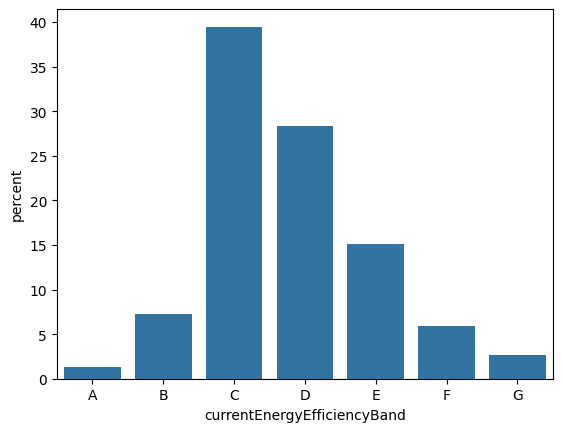

In [9]:

# check distribution of target variable
sns.countplot(data=data_frame, x="currentEnergyEfficiencyBand", stat="percent")

# Compare the constituency Beaconsfield to London

In [11]:
newSearch = Search()
newSearch.constituency = "Cities of London and Westminster"

data = API.get_data(Search.path,**newSearch.params)
next_data_frame = PreProcess.clean(pd.DataFrame(data['data']))

next_data_frame = PreProcess.make_full_address(next_data_frame)
next_data_frame = PreProcess.drop_address_duplicates(next_data_frame)


200
0


In [12]:
# London Shape
next_data_frame.shape

(988, 14)

In [13]:
next_data_frame.isnull().sum()

certificateNumber                0
addressLine1                   420
addressLine2                    54
addressLine3                   366
addressLine4                   915
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      0
registrationDate                 0
uprn                           153
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

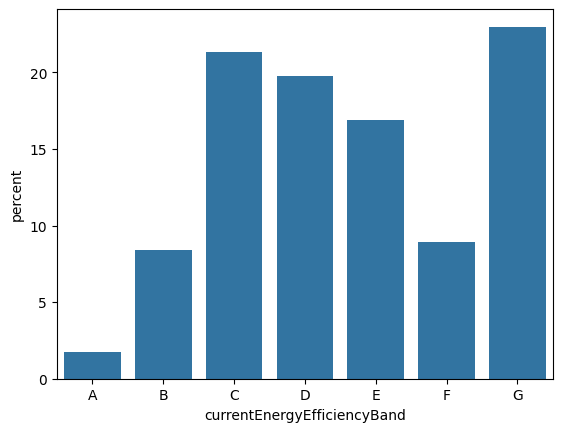

In [14]:
sns.countplot(data=next_data_frame.sort_values(by="currentEnergyEfficiencyBand"), x="currentEnergyEfficiencyBand", stat="percent")

In [15]:
# sub-urban vs urban data 
full_data = pd.concat([data_frame,next_data_frame],ignore_index=True).sort_values(by="currentEnergyEfficiencyBand")
full_data.shape

(1140, 14)

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='proportion'>

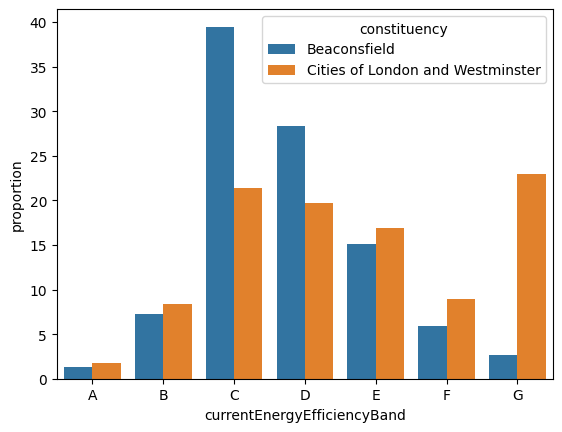

In [16]:
# Make beaconsfield proportionate to london to do an efficiency comparison
comparison = full_data.groupby("constituency")["currentEnergyEfficiencyBand"].value_counts(normalize=True).mul(100).sort_index().reset_index().sort_values(by="currentEnergyEfficiencyBand")

sns.barplot( data=comparison, x="currentEnergyEfficiencyBand", y="proportion", hue="constituency")
# sns.countplot(data=new, x="currentEnergyEfficiencyBand", stat="percent",hue="constituency")

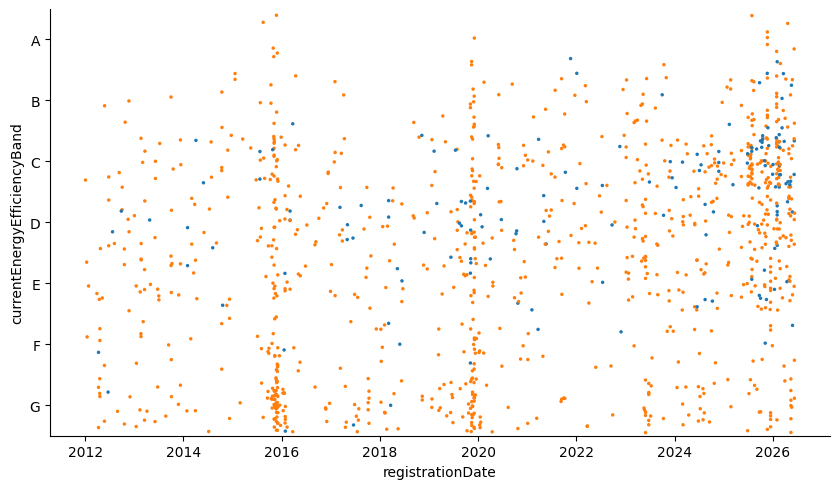

In [17]:
# Are buildings that have registered earlier more or less energy efficent?

full_data["registrationDate"] = pd.to_datetime(full_data["registrationDate"])
full_data["registrationYear"] = full_data["registrationDate"].dt.year
table = sns.catplot(
    data=full_data,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    hue="constituency",
    size=2.5,
    legend=False,
    aspect=1.7
)

table

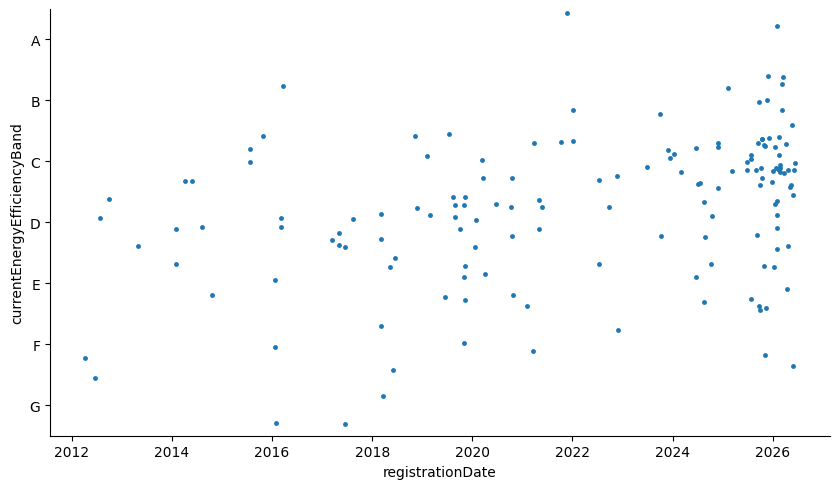

In [18]:
# beaconsfield only

data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
data_frame["registrationYear"] = data_frame["registrationDate"].dt.year
table = sns.catplot(
    data=data_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    size=3.5,
    legend=False,
    aspect=1.7
)

# Feature Engineering with NLP
This first step is to download and install all nltk requirements

In [18]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# !uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0.tar.gz

# import spacy
# NLP = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/silentuser404/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/silentuser404/nltk_data...


True

In [19]:
# Make a new data frame that will include buildings so that older certificates are in the data
newSearch = Search()
newSearch.constituency = "Beaconsfield"

data = API.get_data(Search.path,**newSearch.params)

data_frame = pd.DataFrame(data['data']).sort_values(by="currentEnergyEfficiencyBand")
print(data_frame.shape) #678
data_frame = PreProcess.clean(data_frame)
data_frame = PreProcess.make_full_address(data_frame)

200
(678, 13)
0


In [20]:
# print(hasattr(PreProcess, "remove_stopwords"))
# print(dir(PreProcess))

# Only include 1 building per feature
# data_frame = PreProcess.postcode_duplicates(data_frame) - if buildings have multiple certificates this still wont work.
print(data_frame.shape)

data_frame['tokens'] = data_frame["FullAddress"].apply(PreProcess.format_words)

from nltk import ngrams

N = 2 

building_descriptor = {"combined",
    "primary", "secondary", "junior", "infant", "grammar", "ce", # ce - church of england
    "catholic", "community", "sport", "police", "fire", "medical", 
    "health", "youth", "delivery", "county", "fire", "business","court" , "leisure"
}
building_types = {
    "school","centre","station","office","council", "college"
    "hospital","surgery","library","academy","court",
    "hall","church","nursery","house","complex", "department"
}

def extract_features(tokens):

    bigrams = ngrams(tokens, N)

    for wDesc, wType in bigrams:

        if wDesc == wType:
            continue

        if wType in building_types and wDesc in building_descriptor:
            features = f"{wDesc} {wType}"
            return features
        
    for unigrams in tokens :

        if unigrams in building_types :
            return unigrams

    return None

data_frame["BuildingType"] = data_frame["tokens"].apply(extract_features)

# data_frame.isnull().sum() # only 11 missing building types
  


(676, 14)


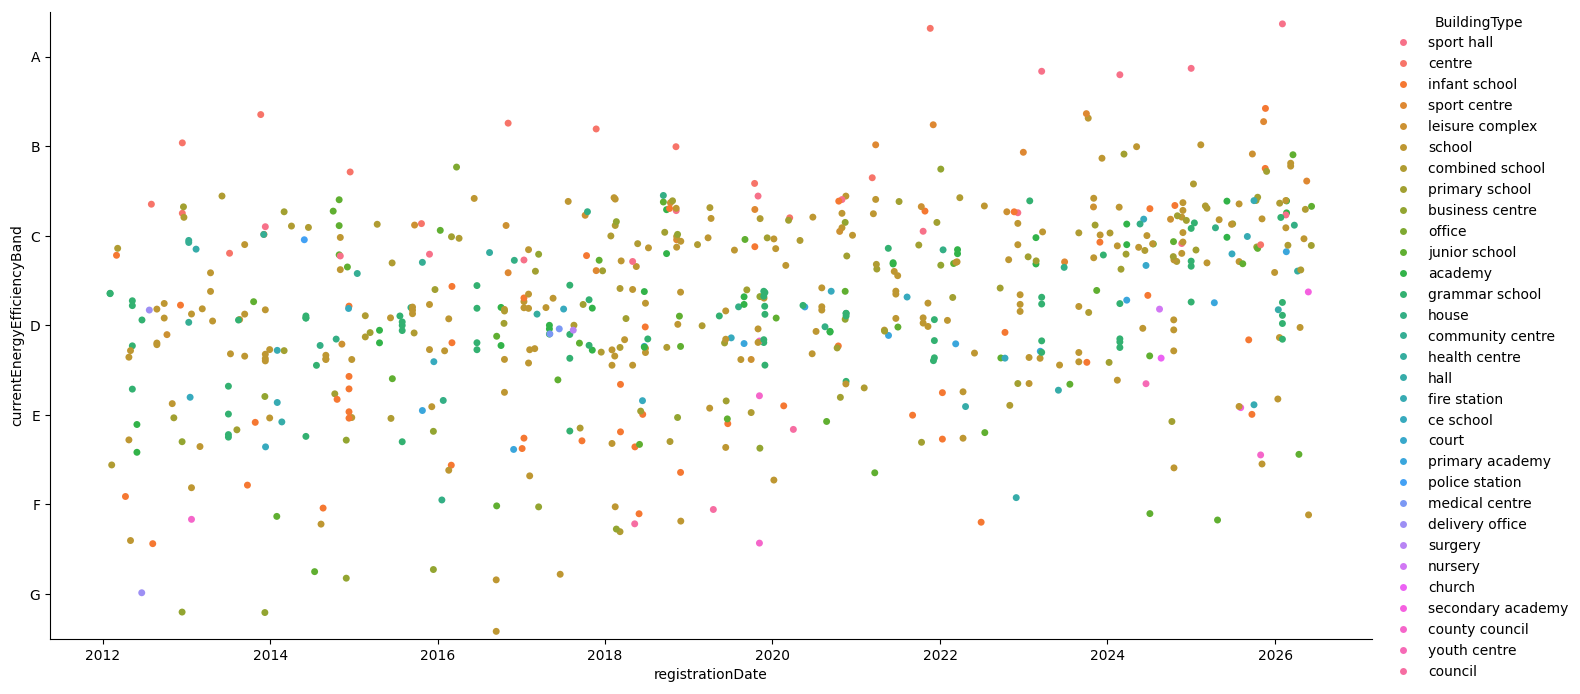

In [21]:
data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
data_frame["registrationYear"] = data_frame["registrationDate"].dt.year
table = sns.catplot(
    data=data_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand",
    hue="BuildingType",
    native_scale=True,
    jitter=0.45,
    kind="strip",
    height=7,
    aspect=2
)

In [22]:
# check for missing values
data_frame.isnull().sum()

certificateNumber                0
addressLine1                   248
addressLine2                     6
addressLine3                   114
addressLine4                   506
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      0
registrationDate                 0
uprn                            31
schemaType                       0
FullAddress                      0
tokens                           0
BuildingType                    38
registrationYear                 0
dtype: int64

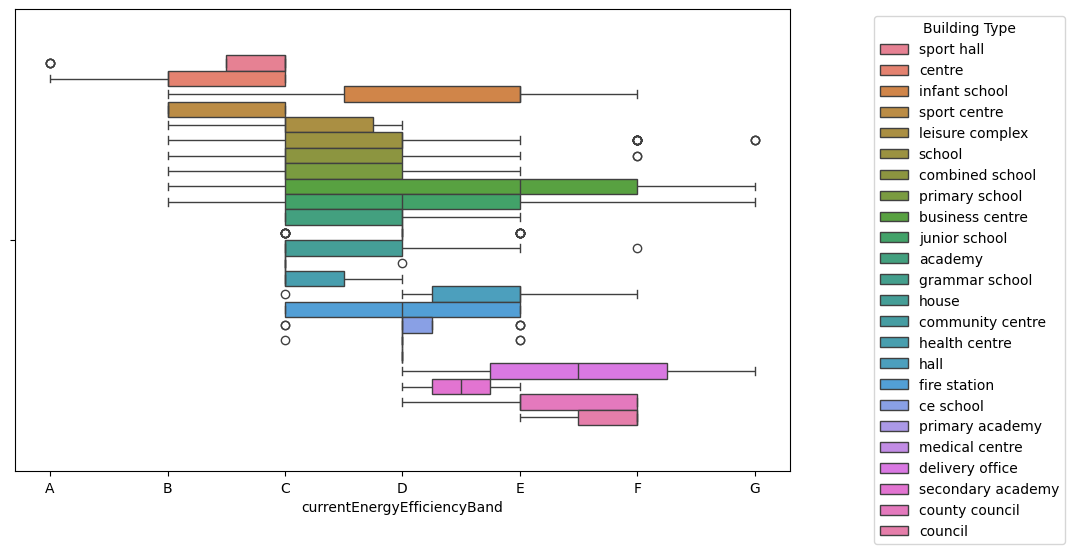

In [23]:
import matplotlib.pyplot as plt
data_dy_frame = data_frame.groupby("BuildingType").filter(lambda x: len(x) > 1)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data_dy_frame,hue="BuildingType",x='currentEnergyEfficiencyBand')
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', title="Building Type")
plt.show()

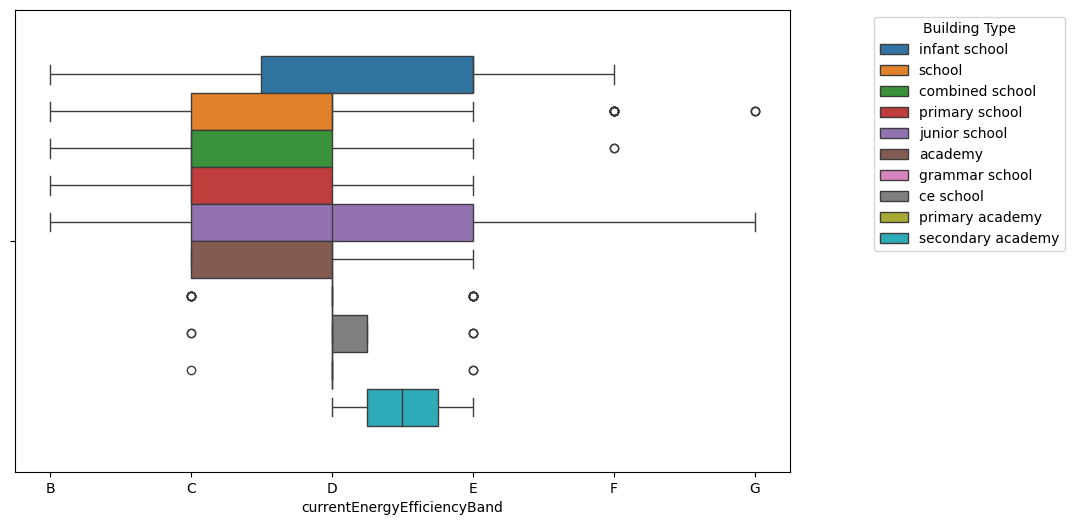

In [24]:
# schools only
school_frame = data_frame.groupby("BuildingType").filter(lambda x: x["BuildingType"].str.contains("school|college|academy").any())
plt.figure(figsize=(10, 6))
sns.boxplot(data=school_frame,hue="BuildingType",x='currentEnergyEfficiencyBand')
plt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', title="Building Type")
plt.show()

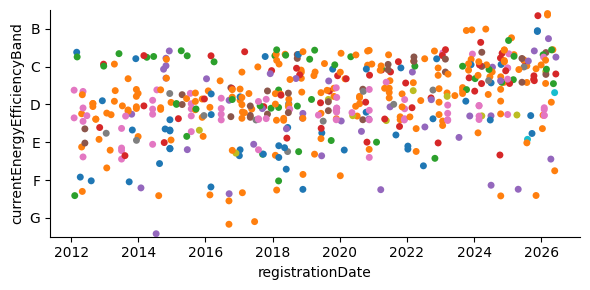

In [25]:
school_frame["registrationDate"] = pd.to_datetime(school_frame["registrationDate"])
school_frame["registrationYear"] = school_frame["registrationDate"].dt.year
table = sns.catplot(
    data=school_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand",
    hue="BuildingType",
    native_scale=True,
    jitter=0.45,
    kind="strip",
    legend= False,
    height=3,
    aspect=2
)

# Machine learning
predictions are made until 2028 using Logistic Regression
The red curve is a polynomial fit showing how the buildings energy efficency may begin to improve.

/home/silentuser404/Documents/GitHub/DataScience/Energy-Ai-consumptions/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


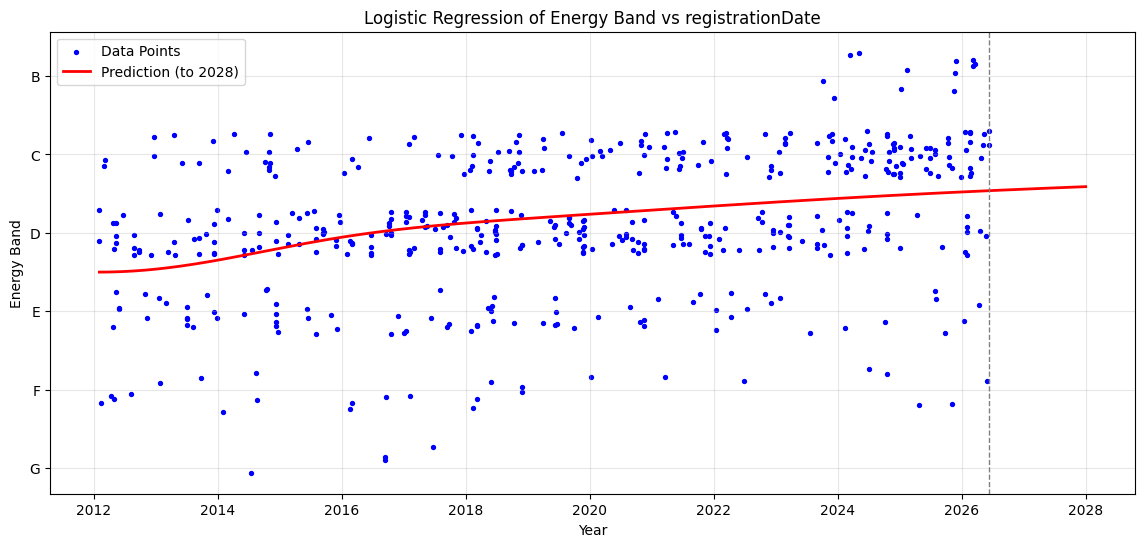

In [26]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression

def plot_polynomial_regression(X, y, feature_name):
    band_order = ['G', 'F', 'E', 'D', 'C', 'B']

    # convert datetime to numeric
    X_squeeze = X.squeeze()
    min_date = X_squeeze.min()
    X_days = (X_squeeze - min_date).dt.days.values.reshape(-1, 1)

    # encode bands
    le = LabelEncoder()
    le.classes_ = np.array(band_order)
    y_encoded = le.transform(y)

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_days)
    # multi_class='multinomial', solver='lbfgs' - on by default
    # standard logistic regression uses binomial
    model = LogisticRegression(max_iter=100, solver='saga')
    model.fit(X_poly, y_encoded)

    end_date = pd.Timestamp('2028-01-01')
    max_days = (end_date - min_date).days
    X_future_days = np.linspace(0, max_days, 500).reshape(-1, 1)
    X_future = poly.transform(X_future_days)

    
    probability = model.predict_proba(X_future)
    class_indices = np.arange(len(band_order))
    # average out the probabilites made with dot product
    y_future = probability @ class_indices

    # convert days back to years 
    min_year_offset = min_date.year + (min_date.month - 1) / 12 + (min_date.day - 1) / 365.25

    X_years = X_days.flatten() / 365.25 + min_year_offset
    X_future_years = X_future_days.flatten() / 365.25 + min_year_offset

    jitter = np.random.uniform(-0.3, 0.3, size=len(y_encoded))

    plt.figure(figsize=(14, 6))
    plt.scatter(
        X_years,
        y_encoded + jitter,
        color='blue', s=8, label='Data Points'
    )
    plt.plot(
        X_future_years,
        y_future,
        color='red', linewidth=2, label='Prediction (to 2028)'
    )

    data_cutoff = X_years.max()
    plt.axvline(data_cutoff, color='grey', linestyle='--', linewidth=1)

    plt.yticks(range(len(band_order)), band_order)
    plt.title(f'Logistic Regression of Energy Band vs {feature_name}')
    plt.xlabel('Year')
    plt.ylabel('Energy Band')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_polynomial_regression(school_frame[['registrationDate']], school_frame['currentEnergyEfficiencyBand'], 'registrationDate')